In [1]:
# ============================================================
# Comparative MD Analysis: Farnesol vs Voriconazole
# CYP51–HEME system
# Input: MD_CORRECTED_COLAB_EXPORT.tar.gz
# ============================================================

from google.colab import files
uploaded = files.upload()

Saving MD_CORRECTED_COLAB_EXPORT.tar.gz to MD_CORRECTED_COLAB_EXPORT.tar.gz


In [2]:
import tarfile
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os

archive = "MD_CORRECTED_COLAB_EXPORT.tar.gz"

with tarfile.open(archive, "r:gz") as tar:
    tar.extractall()

base = Path("MD_CORRECTED_COLAB_EXPORT")
far = base / "Farnesol"
vor = base / "Voriconazole"

outdir = Path("MD_FINAL_PLOTS_AND_TABLES")
outdir.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

/tmp/ipykernel_1697/3611495007.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [3]:
# ----------------------------
# File paths
# ----------------------------

paths = {
    "far_backbone_rmsd": far / "RMSD" / "far_backbone_rmsd.csv",
    "vor_backbone_rmsd": vor / "RMSD" / "vor_backbone_rmsd.csv",

    "far_ligand_rmsd": far / "RMSD" / "far_ligand_rmsd_after_fit.csv",
    "vor_ligand_rmsd": vor / "RMSD" / "vor_ligand_rmsd_after_fit.csv",

    "far_rmsf": far / "RMSF" / "far_backbone_rmsf.csv",
    "vor_rmsf": vor / "RMSF" / "vor_backbone_rmsf.csv",

    "far_rg": far / "RGYR" / "far_gyrate.csv",
    "vor_rg": vor / "RGYR" / "vor_gyrate.csv",

    "far_heme_dist": far / "DISTANCE" / "far_heme_ligand_mindist.csv",
    "vor_heme_dist": vor / "DISTANCE" / "vor_heme_ligand_mindist.csv",

    "far_sasa": far / "SASA" / "far_ligand_sasa.csv",
    "vor_sasa": vor / "SASA" / "vor_ligand_sasa.csv",

    "far_contacts": far / "CONTACTS" / "far_protein_ligand_contacts.csv",
    "vor_contacts": vor / "CONTACTS" / "vor_protein_ligand_contacts.csv",

    "far_cluster": far / "farnesol_cluster_size_100ps.csv",
    "vor_cluster": vor / "vor_cluster_size.csv",
}

for k, p in paths.items():
    print(k, "->", p.exists(), p)

far_backbone_rmsd -> True MD_CORRECTED_COLAB_EXPORT/Farnesol/RMSD/far_backbone_rmsd.csv
vor_backbone_rmsd -> True MD_CORRECTED_COLAB_EXPORT/Voriconazole/RMSD/vor_backbone_rmsd.csv
far_ligand_rmsd -> True MD_CORRECTED_COLAB_EXPORT/Farnesol/RMSD/far_ligand_rmsd_after_fit.csv
vor_ligand_rmsd -> True MD_CORRECTED_COLAB_EXPORT/Voriconazole/RMSD/vor_ligand_rmsd_after_fit.csv
far_rmsf -> True MD_CORRECTED_COLAB_EXPORT/Farnesol/RMSF/far_backbone_rmsf.csv
vor_rmsf -> True MD_CORRECTED_COLAB_EXPORT/Voriconazole/RMSF/vor_backbone_rmsf.csv
far_rg -> True MD_CORRECTED_COLAB_EXPORT/Farnesol/RGYR/far_gyrate.csv
vor_rg -> True MD_CORRECTED_COLAB_EXPORT/Voriconazole/RGYR/vor_gyrate.csv
far_heme_dist -> True MD_CORRECTED_COLAB_EXPORT/Farnesol/DISTANCE/far_heme_ligand_mindist.csv
vor_heme_dist -> True MD_CORRECTED_COLAB_EXPORT/Voriconazole/DISTANCE/vor_heme_ligand_mindist.csv
far_sasa -> True MD_CORRECTED_COLAB_EXPORT/Farnesol/SASA/far_ligand_sasa.csv
vor_sasa -> True MD_CORRECTED_COLAB_EXPORT/Voriconazo

In [10]:
def read_cluster(path):
    df = pd.read_csv(
        path,
        header=None,
        sep=r"[,\s]+",
        engine="python"
    )

    df = df.iloc[:, :2]
    df.columns = ["Cluster", "Frames"]

    df["Cluster"] = pd.to_numeric(df["Cluster"], errors="coerce")
    df["Frames"] = pd.to_numeric(df["Frames"], errors="coerce")

    df = df.dropna()

    df["Percent"] = df["Frames"] / df["Frames"].sum() * 100

    return df

In [11]:
far_cluster = read_cluster(paths["far_cluster"])
vor_cluster = read_cluster(paths["vor_cluster"])

print(far_cluster)
print(vor_cluster)
print("Cluster files loaded successfully.")

    Cluster  Frames    Percent
0         1    1032  51.574213
1         2     860  42.978511
2         3      90   4.497751
3         4       8   0.399800
4         5       1   0.049975
5         6       1   0.049975
6         7       1   0.049975
7         8       1   0.049975
8         9       1   0.049975
9        10       1   0.049975
10       11       1   0.049975
11       12       1   0.049975
12       13       1   0.049975
13       14       1   0.049975
14       15       1   0.049975
   Cluster  Frames  Percent
0        1    2001    100.0
Cluster files loaded successfully.


In [12]:
# ----------------------------
# Load data
# ----------------------------

far_backbone_rmsd = read_time_series(paths["far_backbone_rmsd"])
vor_backbone_rmsd = read_time_series(paths["vor_backbone_rmsd"])

far_ligand_rmsd = read_time_series(paths["far_ligand_rmsd"])
vor_ligand_rmsd = read_time_series(paths["vor_ligand_rmsd"])

far_rmsf = read_rmsf(paths["far_rmsf"])
vor_rmsf = read_rmsf(paths["vor_rmsf"])

far_rg = read_time_series(paths["far_rg"])
vor_rg = read_time_series(paths["vor_rg"])

far_heme_dist = read_time_series(paths["far_heme_dist"])
vor_heme_dist = read_time_series(paths["vor_heme_dist"])

far_sasa = read_time_series(paths["far_sasa"])
vor_sasa = read_time_series(paths["vor_sasa"])

far_contacts = read_time_series(paths["far_contacts"])
vor_contacts = read_time_series(paths["vor_contacts"])

far_cluster = read_cluster(paths["far_cluster"])
vor_cluster = read_cluster(paths["vor_cluster"])

print("All datasets loaded.")

All datasets loaded.


In [13]:
# ----------------------------
# Plot functions
# ----------------------------

def plot_compare(far_df, vor_df, ylabel, title, filename):
    plt.figure(figsize=(9, 5))
    plt.plot(far_df["Time_ns"], far_df["Value"], label="Farnesol", linewidth=1)
    plt.plot(vor_df["Time_ns"], vor_df["Value"], label="Voriconazole", linewidth=1)
    plt.xlabel("Time (ns)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outdir / filename, dpi=600)
    plt.show()

def plot_rmsf(far_df, vor_df):
    plt.figure(figsize=(10, 5))
    plt.plot(far_df["Residue"], far_df["RMSF"], label="Farnesol", linewidth=1)
    plt.plot(vor_df["Residue"], vor_df["RMSF"], label="Voriconazole", linewidth=1)
    plt.xlabel("Residue number")
    plt.ylabel("RMSF (nm)")
    plt.title("Protein Backbone RMSF Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(outdir / "07_Backbone_RMSF_Comparison.png", dpi=600)
    plt.show()

def plot_cluster(df, system, filename):
    plt.figure(figsize=(8, 5))
    plt.bar(df["Cluster"].astype(str), df["Percent"])
    plt.xlabel("Cluster ID")
    plt.ylabel("Population (%)")
    plt.title(f"{system} Cluster Population")
    plt.tight_layout()
    plt.savefig(outdir / filename, dpi=600)
    plt.show()

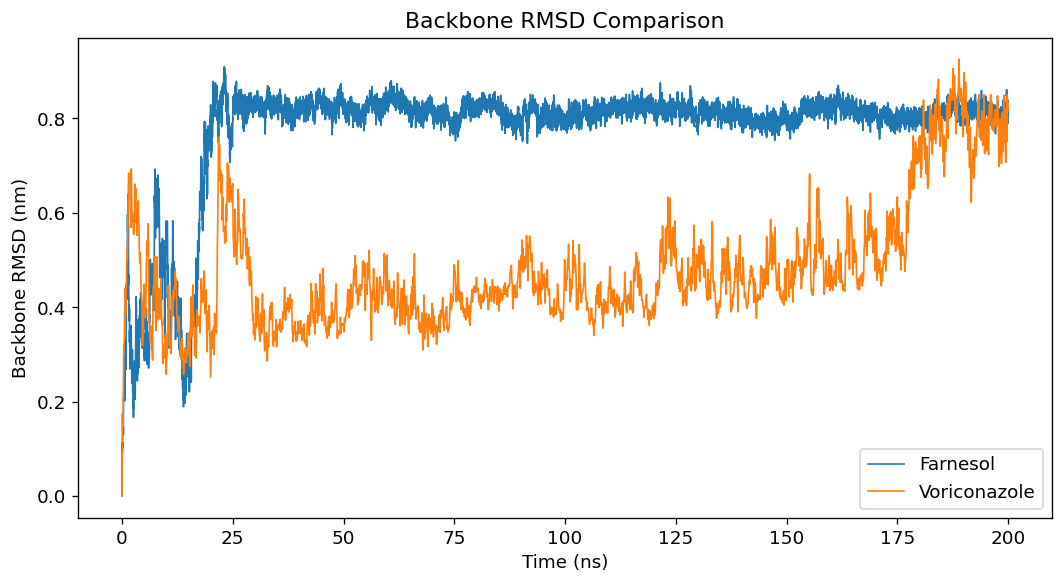

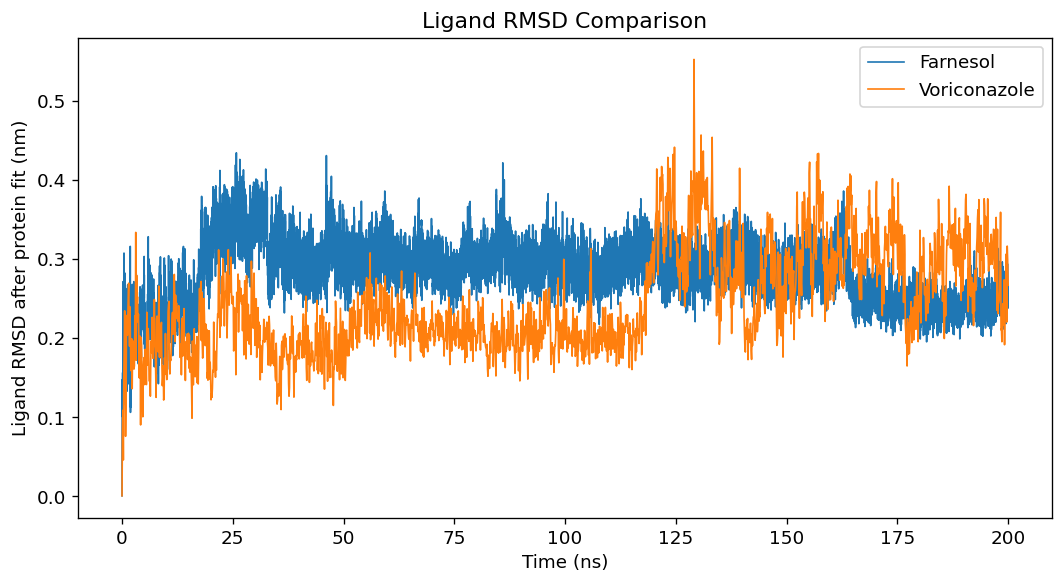

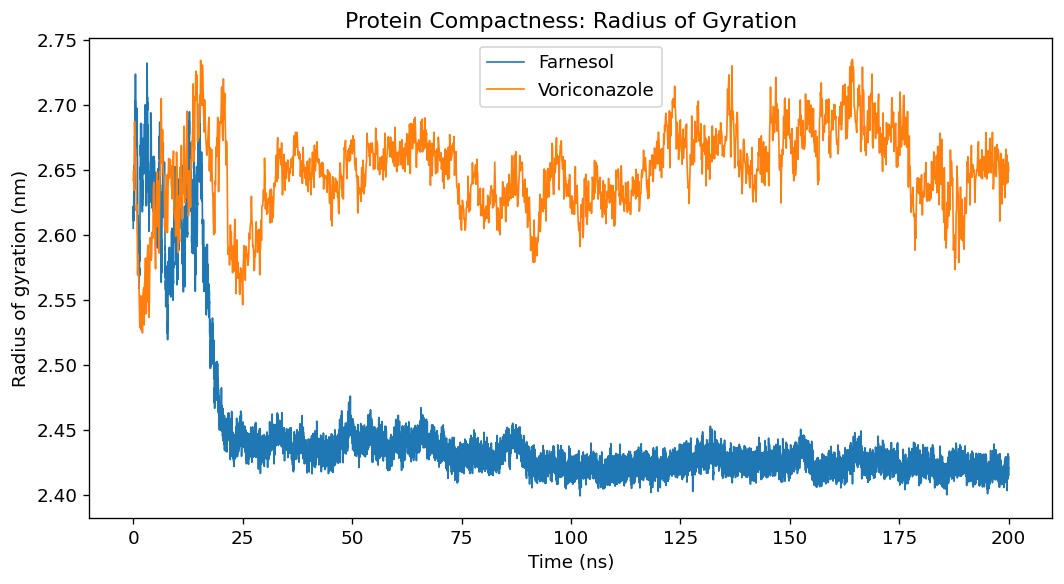

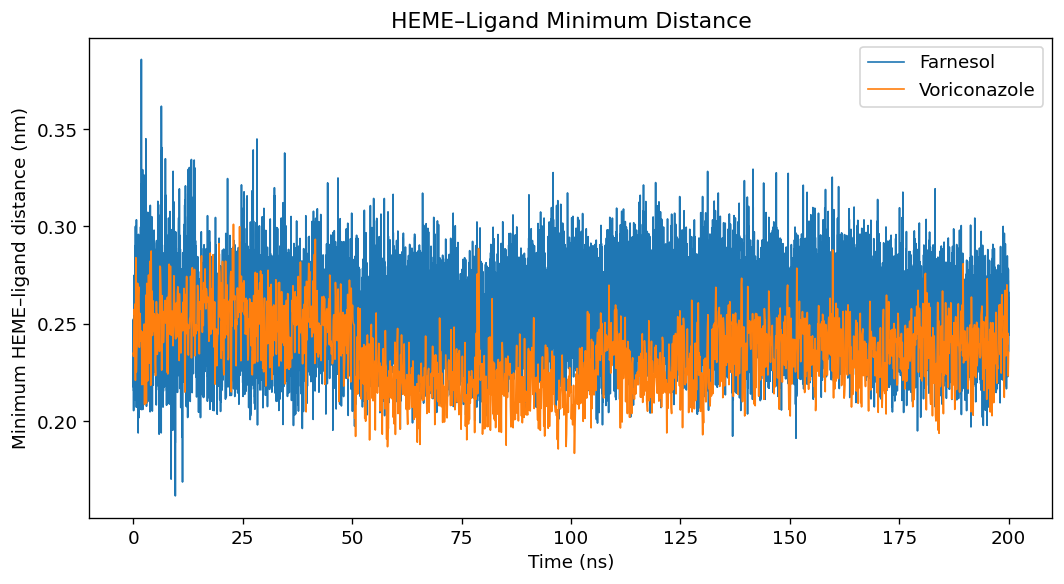

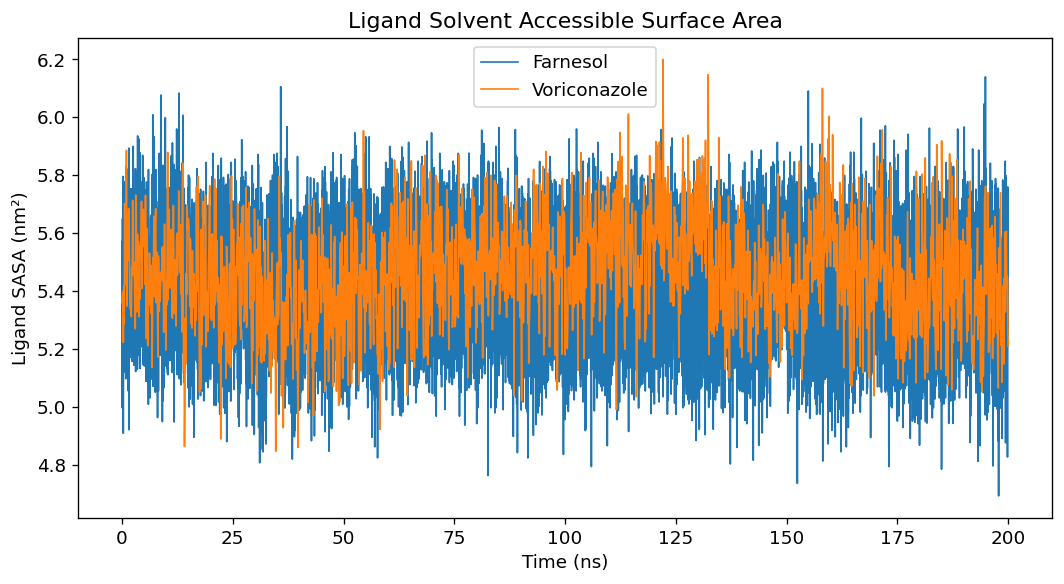

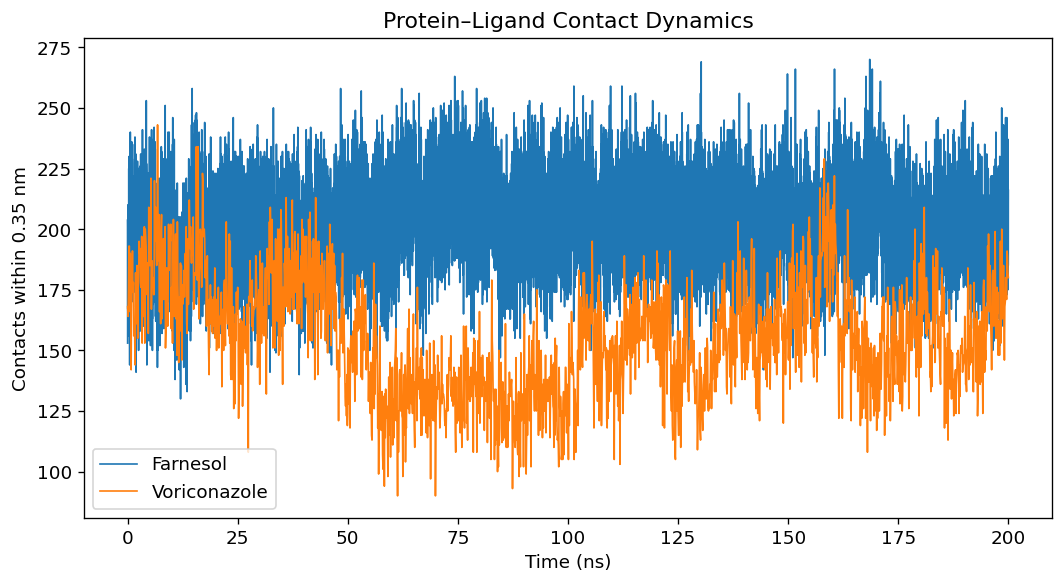

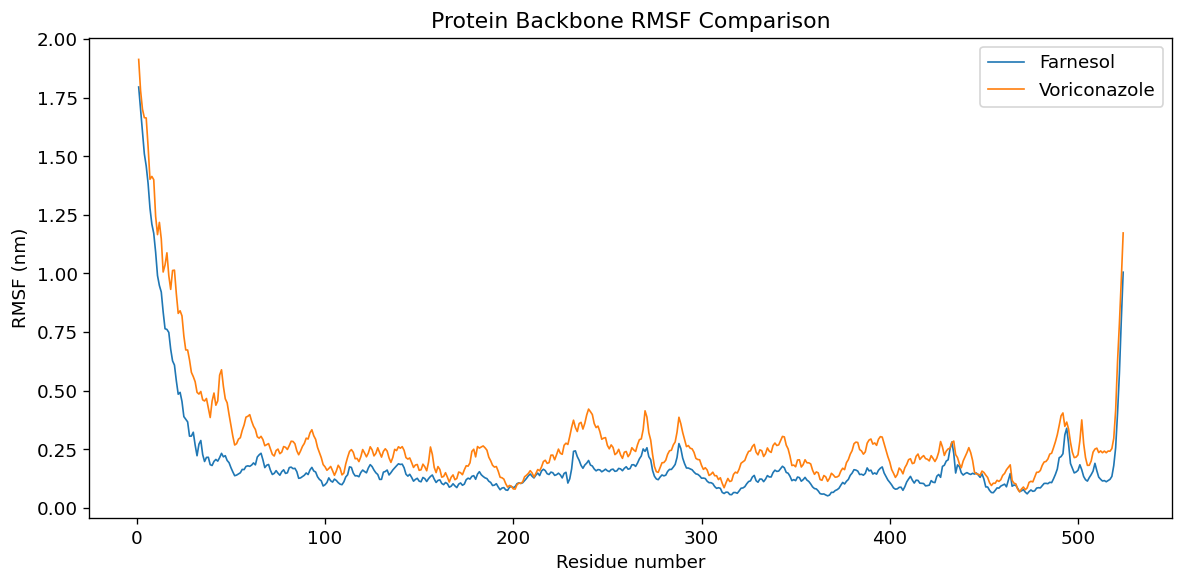

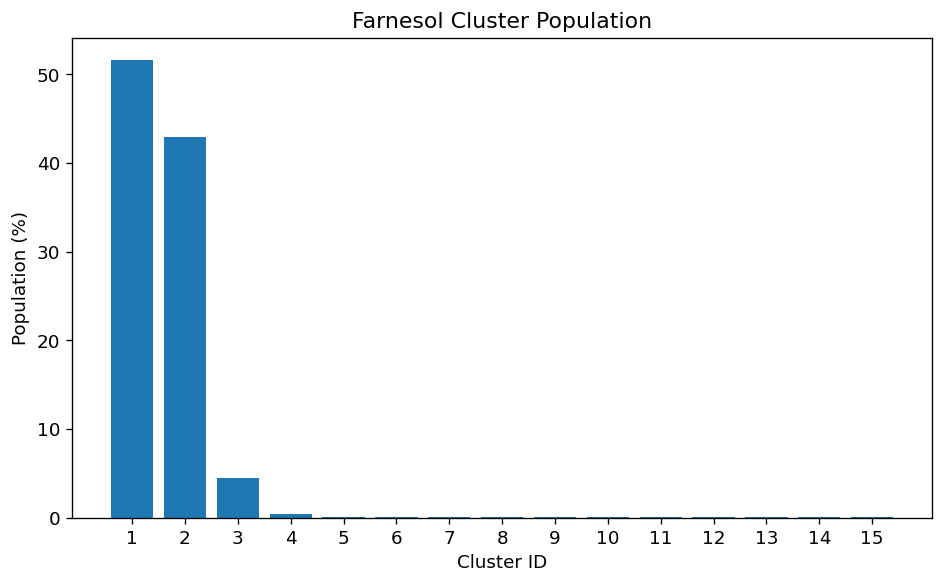

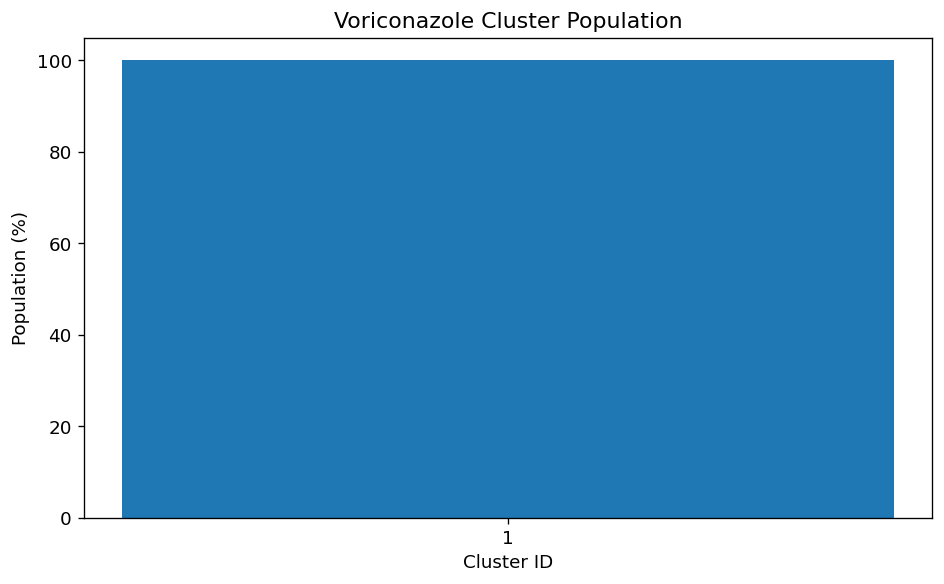

In [14]:
# ----------------------------
# Generate plots
# ----------------------------

plot_compare(
    far_backbone_rmsd,
    vor_backbone_rmsd,
    "Backbone RMSD (nm)",
    "Backbone RMSD Comparison",
    "01_Backbone_RMSD_Comparison.png"
)

plot_compare(
    far_ligand_rmsd,
    vor_ligand_rmsd,
    "Ligand RMSD after protein fit (nm)",
    "Ligand RMSD Comparison",
    "02_Ligand_RMSD_Comparison.png"
)

plot_compare(
    far_rg,
    vor_rg,
    "Radius of gyration (nm)",
    "Protein Compactness: Radius of Gyration",
    "03_Radius_of_Gyration_Comparison.png"
)

plot_compare(
    far_heme_dist,
    vor_heme_dist,
    "Minimum HEME–ligand distance (nm)",
    "HEME–Ligand Minimum Distance",
    "04_HEME_Ligand_Distance_Comparison.png"
)

plot_compare(
    far_sasa,
    vor_sasa,
    "Ligand SASA (nm²)",
    "Ligand Solvent Accessible Surface Area",
    "05_Ligand_SASA_Comparison.png"
)

plot_compare(
    far_contacts,
    vor_contacts,
    "Contacts within 0.35 nm",
    "Protein–Ligand Contact Dynamics",
    "06_Protein_Ligand_Contacts_Comparison.png"
)

plot_rmsf(far_rmsf, vor_rmsf)

plot_cluster(
    far_cluster,
    "Farnesol",
    "08_Farnesol_Cluster_Population.png"
)

plot_cluster(
    vor_cluster,
    "Voriconazole",
    "09_Voriconazole_Cluster_Population.png"
)

In [15]:
# ----------------------------
# Summary statistics
# ----------------------------

def summarize(metric, system, df):
    return {
        "Metric": metric,
        "System": system,
        "Mean": df["Value"].mean(),
        "SD": df["Value"].std(),
        "Min": df["Value"].min(),
        "Max": df["Value"].max(),
        "Median": df["Value"].median()
    }

summary_rows = []

summary_rows += [
    summarize("Backbone RMSD", "Farnesol", far_backbone_rmsd),
    summarize("Backbone RMSD", "Voriconazole", vor_backbone_rmsd),

    summarize("Ligand RMSD", "Farnesol", far_ligand_rmsd),
    summarize("Ligand RMSD", "Voriconazole", vor_ligand_rmsd),

    summarize("Radius of Gyration", "Farnesol", far_rg),
    summarize("Radius of Gyration", "Voriconazole", vor_rg),

    summarize("HEME–Ligand Distance", "Farnesol", far_heme_dist),
    summarize("HEME–Ligand Distance", "Voriconazole", vor_heme_dist),

    summarize("Ligand SASA", "Farnesol", far_sasa),
    summarize("Ligand SASA", "Voriconazole", vor_sasa),

    summarize("Protein–Ligand Contacts", "Farnesol", far_contacts),
    summarize("Protein–Ligand Contacts", "Voriconazole", vor_contacts),
]

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(outdir / "Comparative_MD_Summary_Statistics.csv", index=False)
summary_df

,Metric,System,Mean,SD,Min,Max,Median
0,Backbone RMSD,Farnesol,0.775733,0.128017,0.000500,0.908721,0.812821
1,Backbone RMSD,Voriconazole,0.479210,0.129153,0.000495,0.924647,0.443532
2,Ligand RMSD,Farnesol,0.283581,0.038482,0.000470,0.434334,0.286380
3,Ligand RMSD,Voriconazole,0.243483,0.064711,0.000526,0.552483,0.227438
4,Radius of Gyration,Farnesol,2.446447,0.055962,2.399320,2.732205,2.429135
5,Radius of Gyration,Voriconazole,2.649541,0.031797,2.524705,2.735063,2.651686
6,HEME–Ligand Distance,Farnesol,0.255741,0.019911,0.161644,0.385795,0.256244
7,HEME–Ligand Distance,Voriconazole,0.234632,0.019542,0.183485,0.301108,0.234359
8,Ligand SASA,Farnesol,5.414372,0.175589,4.693000,6.139000,5.417000
9,Ligand SASA,Voriconazole,5.463182,0.186623,4.847000,6.199000,5.466000


In [16]:
# ----------------------------
# RMSF summary
# ----------------------------

rmsf_summary = pd.DataFrame([
    {
        "System": "Farnesol",
        "Mean_RMSF": far_rmsf["RMSF"].mean(),
        "SD_RMSF": far_rmsf["RMSF"].std(),
        "Max_RMSF": far_rmsf["RMSF"].max(),
        "Residue_Max_RMSF": far_rmsf.loc[far_rmsf["RMSF"].idxmax(), "Residue"]
    },
    {
        "System": "Voriconazole",
        "Mean_RMSF": vor_rmsf["RMSF"].mean(),
        "SD_RMSF": vor_rmsf["RMSF"].std(),
        "Max_RMSF": vor_rmsf["RMSF"].max(),
        "Residue_Max_RMSF": vor_rmsf.loc[vor_rmsf["RMSF"].idxmax(), "Residue"]
    }
])

rmsf_summary.to_csv(outdir / "RMSF_Summary.csv", index=False)
rmsf_summary

,System,Mean_RMSF,SD_RMSF,Max_RMSF,Residue_Max_RMSF
0,Farnesol,0.185524,0.211579,1.7952,1
1,Voriconazole,0.284990,0.247355,1.9129,1


In [17]:
# ----------------------------
# Cluster summary
# ----------------------------

far_cluster_out = far_cluster.copy()
far_cluster_out["System"] = "Farnesol"

vor_cluster_out = vor_cluster.copy()
vor_cluster_out["System"] = "Voriconazole"

cluster_summary = pd.concat(
    [far_cluster_out, vor_cluster_out],
    ignore_index=True
)

cluster_summary = cluster_summary[
    ["System", "Cluster", "Frames", "Percent"]
]

cluster_summary.to_csv(outdir / "Cluster_Population_Summary.csv", index=False)
cluster_summary

,System,Cluster,Frames,Percent
0,Farnesol,1,1032,51.574213
1,Farnesol,2,860,42.978511
2,Farnesol,3,90,4.497751
3,Farnesol,4,8,0.399800
4,Farnesol,5,1,0.049975
5,Farnesol,6,1,0.049975
6,Farnesol,7,1,0.049975
7,Farnesol,8,1,0.049975
8,Farnesol,9,1,0.049975
9,Farnesol,10,1,0.049975


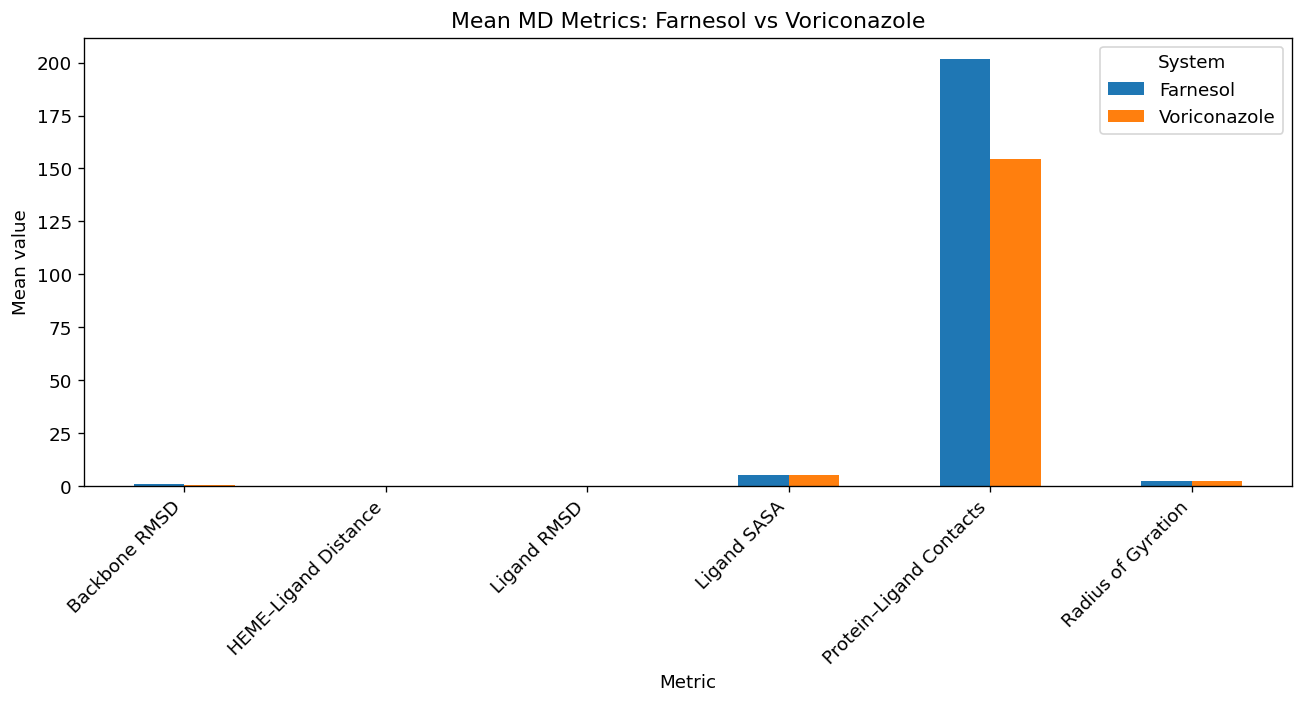

System,Farnesol,Voriconazole
Metric,,
Backbone RMSD,0.775733,0.479210
HEME–Ligand Distance,0.255741,0.234632
Ligand RMSD,0.283581,0.243483
Ligand SASA,5.414372,5.463182
Protein–Ligand Contacts,201.696815,154.569715
Radius of Gyration,2.446447,2.649541


In [18]:
# ----------------------------
# Combined summary bar plots
# ----------------------------

mean_table = summary_df.pivot(
    index="Metric",
    columns="System",
    values="Mean"
)

mean_table.plot(kind="bar", figsize=(11, 6))
plt.ylabel("Mean value")
plt.title("Mean MD Metrics: Farnesol vs Voriconazole")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(outdir / "10_Mean_MD_Metrics_Barplot.png", dpi=600)
plt.show()

mean_table

In [19]:
# ----------------------------
# Save manuscript interpretation
# ----------------------------

interpretation = f"""
Comparative Molecular Dynamics Interpretation

The corrected MD analysis compared Farnesol and Voriconazole bound to the CYP51–HEME system over 200 ns.

Backbone RMSD:
Farnesol mean backbone RMSD = {far_backbone_rmsd['Value'].mean():.3f} nm.
Voriconazole mean backbone RMSD = {vor_backbone_rmsd['Value'].mean():.3f} nm.

Ligand RMSD:
Farnesol mean ligand RMSD = {far_ligand_rmsd['Value'].mean():.3f} nm.
Voriconazole mean ligand RMSD = {vor_ligand_rmsd['Value'].mean():.3f} nm.

HEME–Ligand Distance:
Farnesol mean HEME–ligand distance = {far_heme_dist['Value'].mean():.3f} nm.
Voriconazole mean HEME–ligand distance = {vor_heme_dist['Value'].mean():.3f} nm.

Ligand SASA:
Farnesol mean ligand SASA = {far_sasa['Value'].mean():.3f} nm².
Voriconazole mean ligand SASA = {vor_sasa['Value'].mean():.3f} nm².

Protein–Ligand Contacts:
Farnesol mean contacts = {far_contacts['Value'].mean():.2f}.
Voriconazole mean contacts = {vor_contacts['Value'].mean():.2f}.

Cluster Analysis:
Farnesol distributed across {len(far_cluster)} clusters, with the two dominant clusters accounting for {far_cluster['Percent'].iloc[0]:.2f}% and {far_cluster['Percent'].iloc[1]:.2f}% of frames.
Voriconazole showed {len(vor_cluster)} cluster(s), with the dominant cluster accounting for {vor_cluster['Percent'].iloc[0]:.2f}% of frames.

Interpretation:
Voriconazole shows a more rigid single-state binding mode, consistent with stable inhibitor-like behavior near the CYP51 heme pocket. Farnesol shows dynamic but persistent binding behavior, characterized by multiple conformational states, sustained heme proximity, and broad protein-ligand contacts.
"""

with open(outdir / "Manuscript_MD_Interpretation.txt", "w") as f:
    f.write(interpretation)

print(interpretation)


Comparative Molecular Dynamics Interpretation

The corrected MD analysis compared Farnesol and Voriconazole bound to the CYP51–HEME system over 200 ns.

Backbone RMSD:
Farnesol mean backbone RMSD = 0.776 nm.
Voriconazole mean backbone RMSD = 0.479 nm.

Ligand RMSD:
Farnesol mean ligand RMSD = 0.284 nm.
Voriconazole mean ligand RMSD = 0.243 nm.

HEME–Ligand Distance:
Farnesol mean HEME–ligand distance = 0.256 nm.
Voriconazole mean HEME–ligand distance = 0.235 nm.

Ligand SASA:
Farnesol mean ligand SASA = 5.414 nm².
Voriconazole mean ligand SASA = 5.463 nm².

Protein–Ligand Contacts:
Farnesol mean contacts = 201.70.
Voriconazole mean contacts = 154.57.

Cluster Analysis:
Farnesol distributed across 15 clusters, with the two dominant clusters accounting for 51.57% and 42.98% of frames.
Voriconazole showed 1 cluster(s), with the dominant cluster accounting for 100.00% of frames.

Interpretation:
Voriconazole shows a more rigid single-state binding mode, consistent with stable inhibitor-li